In [17]:
!pip -q install datasets transformers evaluate scikit-learn matplotlib pandas numpy gradio nltk wordcloud tqdm gensim torch

In [18]:
# Nếu cần cài thêm package, bỏ comment các dòng dưới đây trong môi trường mới:
# !pip -q install datasets transformers evaluate scikit-learn matplotlib pandas numpy torch gradio nltk wordcloud tqdm

import os
import re
import json
import math
import time
import copy
import random
import warnings
from dataclasses import dataclass, asdict
from collections import Counter, defaultdict
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import html
import unicodedata
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import textwrap
from IPython.display import display, HTML

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

OUTPUT_DIR = "outputs_patent_text_classification_v2"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
CKPT_DIR = os.path.join(OUTPUT_DIR, "checkpoints")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

# ===== Dataset / experiment config =====
DATASET_NAME = "MAdAiLab/patent_classification"
RUN_ALL_EXPERIMENTS = True

# RNN config
RNN_MAX_VOCAB = 40000
RNN_MAX_LEN = 350
RNN_BATCH_SIZE = 32
RNN_EPOCHS = 4

# Transformer config
TRANSFORMER_MAX_LEN = 256
TRANSFORMER_BATCH_SIZE = 8
TRANSFORMER_EPOCHS = 3
GRAD_ACCUM_STEPS = 2

# Hybrid config
HYBRID_MAX_LEN = 256
HYBRID_BATCH_SIZE = 8
HYBRID_EPOCHS = 3

print("Output dir:", OUTPUT_DIR)

Device: cuda
Output dir: outputs_patent_text_classification_v2


In [19]:
from datasets import load_dataset

ds = load_dataset(DATASET_NAME)
print(ds)

print("\nSplits:", list(ds.keys()))
for split in ds.keys():
    print(split, "num_rows =", len(ds[split]))
    print("columns:", ds[split].column_names)
    print("features:", ds[split].features)
    print("-" * 80)

def infer_text_and_label_columns(dataset_split):
    cols = dataset_split.column_names
    features = dataset_split.features

    # 1) label candidates
    label_col = None
    for c in cols:
        feat = features[c]
        if feat.__class__.__name__ == "ClassLabel":
            label_col = c
            break
    if label_col is None:
        known_label_names = {"label", "labels", "target", "category", "class", "y"}
        for c in cols:
            if c.lower() in known_label_names:
                label_col = c
                break
    if label_col is None:
        numeric_candidates = []
        for c in cols:
            if c == label_col:
                continue
            values = dataset_split[c][:200]
            if all(isinstance(v, (int, np.integer)) for v in values if v is not None):
                numeric_candidates.append((c, len(set(values))))
        if numeric_candidates:
            numeric_candidates.sort(key=lambda x: x[1])
            label_col = numeric_candidates[0][0]

    # 2) text candidates: choose string column with the largest average length
    text_candidates = []
    for c in cols:
        feat = features[c]
        if feat.__class__.__name__ == "Value" and getattr(feat, "dtype", None) in ("string", "large_string"):
            sample = [str(x) for x in dataset_split[c][:200]]
            avg_len = np.mean([len(x) for x in sample]) if sample else 0
            text_candidates.append((c, avg_len))
        elif feat.__class__.__name__ == "ClassLabel":
            continue
    if not text_candidates:
        for c in cols:
            if c == label_col:
                continue
            sample = [str(x) for x in dataset_split[c][:100]]
            avg_len = np.mean([len(x) for x in sample]) if sample else 0
            text_candidates.append((c, avg_len))
    text_candidates.sort(key=lambda x: x[1], reverse=True)
    text_col = text_candidates[0][0] if text_candidates else None

    return text_col, label_col

TEXT_COL, LABEL_COL = infer_text_and_label_columns(ds["train"])
print("TEXT_COL =", TEXT_COL)
print("LABEL_COL =", LABEL_COL)

assert TEXT_COL in ds["train"].column_names, f"Cannot find text column: {TEXT_COL}"
assert LABEL_COL in ds["train"].column_names, f"Cannot find label column: {LABEL_COL}"

def get_label_names(dataset_split, label_col):
    feat = dataset_split.features[label_col]
    if feat.__class__.__name__ == "ClassLabel":
        return list(feat.names)
    raw = dataset_split[label_col]
    uniq = sorted(set(raw))
    return [str(x) for x in uniq]

label_names = get_label_names(ds["train"], LABEL_COL)
num_labels = len(label_names)
label2id = {name: i for i, name in enumerate(label_names)}
id2label = {i: name for name, i in label2id.items()}

print("\nNumber of labels:", num_labels)
print("Label names:")
for i, name in enumerate(label_names):
    print(i, name)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 5000
    })
})

Splits: ['train', 'validation', 'test']
train num_rows = 25000
columns: ['text', 'label']
features: {'text': Value('string'), 'label': ClassLabel(names=['Human Necessities', 'Performing Operations; Transporting', 'Chemistry; Metallurgy', 'Textiles; Paper', 'Fixed Constructions', 'Mechanical Engineering; Lightning; Heating; Weapons; Blasting', 'Physics', 'Electricity', 'General tagging of new or cross-sectional technology'])}
--------------------------------------------------------------------------------
validation num_rows = 5000
columns: ['text', 'label']
features: {'text': Value('string'), 'label': ClassLabel(names=['Human Necessities', 'Performing Operations; Transporting', 'Chemistry; Metallurgy', '

In [20]:
# =========================
# 1. STOPWORDS
# =========================
try:
    import nltk
    from nltk.corpus import stopwords
    from nltk.stem import WordNetLemmatizer

    STOPWORDS = set(stopwords.words("english"))
    LEMMATIZER = WordNetLemmatizer()
    HAS_NLTK = True
except:
    from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
    STOPWORDS = set(ENGLISH_STOP_WORDS)
    LEMMATIZER = None
    HAS_NLTK = False

# giữ phủ định
KEEP_WORDS = {"no", "not", "nor", "never", "without"}
STOPWORDS = STOPWORDS - KEEP_WORDS

# thêm domain stopwords (patent)
CUSTOM_STOPWORDS = {
    "thereof", "therein", "herein", "hereof", "wherein", "whereby",
    "said", "may", "also"
}
STOPWORDS = STOPWORDS.union(CUSTOM_STOPWORDS)

# =========================
# 2. CLEAN TEXT
# =========================
def clean_text(text):
    text = str(text)
    text = html.unescape(text)
    text = unicodedata.normalize("NFKC", text)
    text = text.lower()

    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)

    # số -> <num>
    text = re.sub(r"\b\d+(\.\d+)?\b", " <num> ", text)

    text = re.sub(r"[-_/\\]+", " ", text)
    text = re.sub(r"[^a-z0-9<>\s]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_simple(text):
    text = clean_text(text)
    tokens = re.findall(r"<num>|[a-z]+", text)

    out = []
    for tok in tokens:
        if tok == "<num>":
            out.append(tok)
            continue

        if tok in STOPWORDS:
            continue

        if LEMMATIZER is not None:
            try:
                tok = LEMMATIZER.lemmatize(tok)
            except:
                pass

        if len(tok) >= 2:
            out.append(tok)

    return out

,text,label,label_name,char_len,word_len,split
0,an apparatus for simultaneously testing multip...,6,Physics,1314,212,train
1,an electrosurgical instrument includes a housi...,0,Human Necessities,925,154,train
2,a wireless transceiver device employing the co...,7,Electricity,539,86,train


(25000, 6) (5000, 6) (5000, 6)


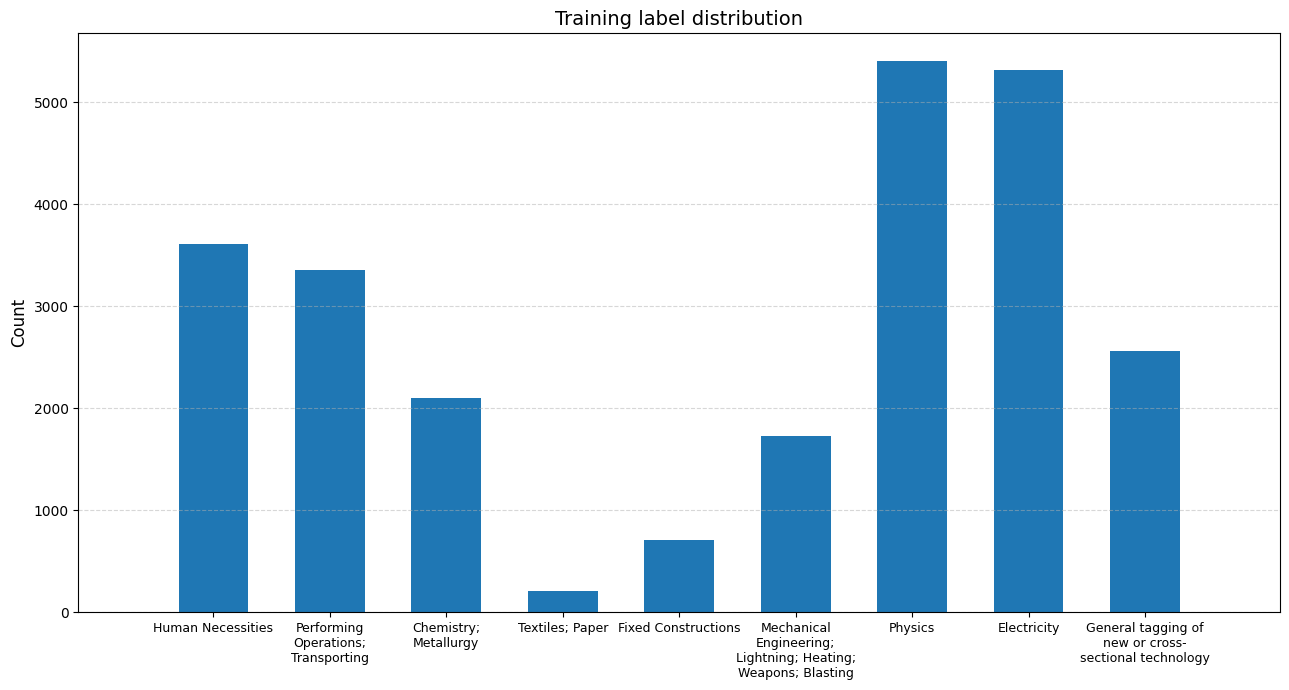

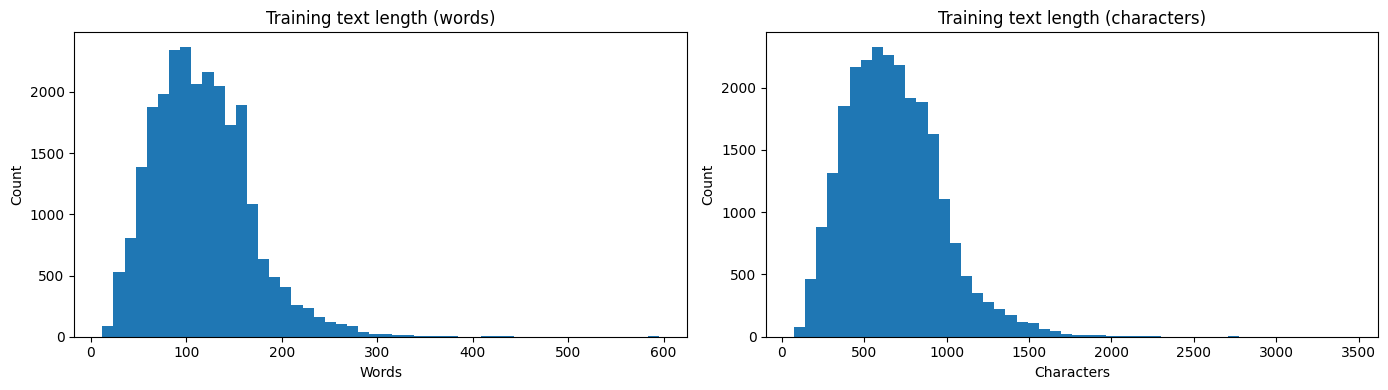

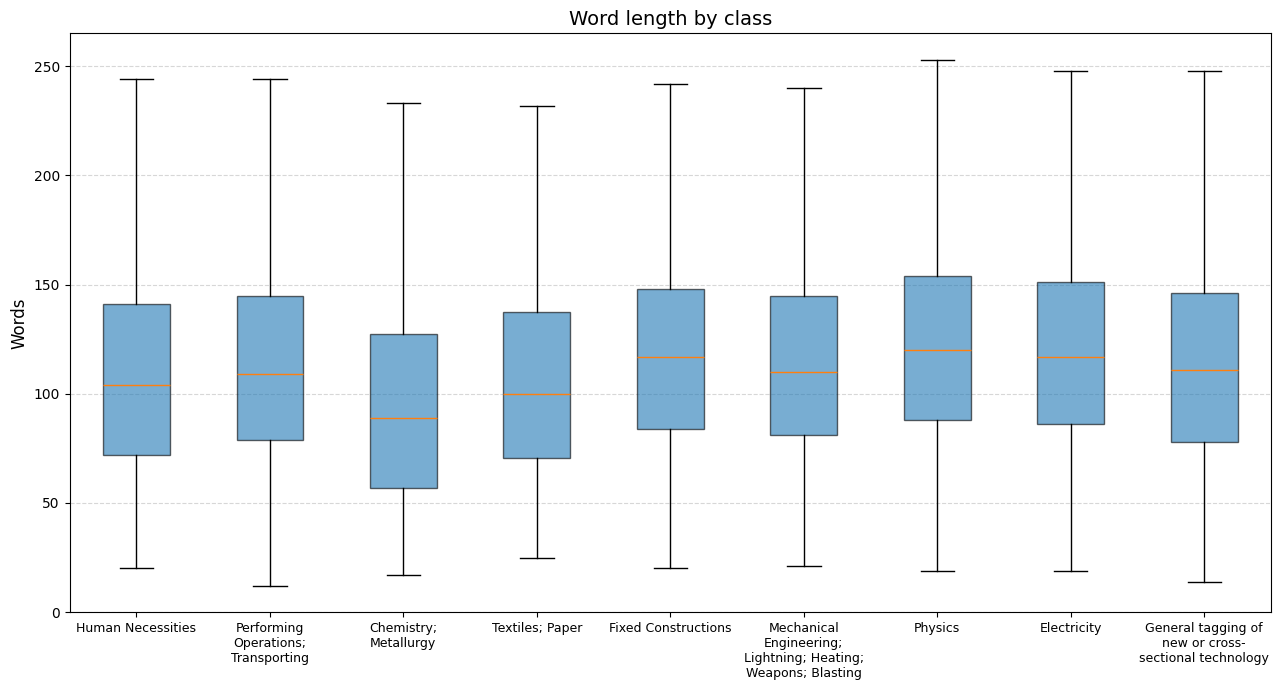

,text,label_name
0,a device for improving the hearing acuity of a...,Human Necessities
1,an animal training device and system which use...,Human Necessities
2,the interface is an apparatus that is attached...,Performing Operations; Transporting
3,the invention relates to a roller press having...,Performing Operations; Transporting
4,"the disclosure includes a method , process and...",Chemistry; Metallurgy
5,the present invention provides improved proces...,Chemistry; Metallurgy
6,"a hydrophobic , liquid - impermeable substrate...",Textiles; Paper
7,a method of cleaning a washing tub mounted in ...,Textiles; Paper
8,"a vapor blow through avoidance method , proces...",Fixed Constructions
9,the invention relates to modular building bloc...,Fixed Constructions


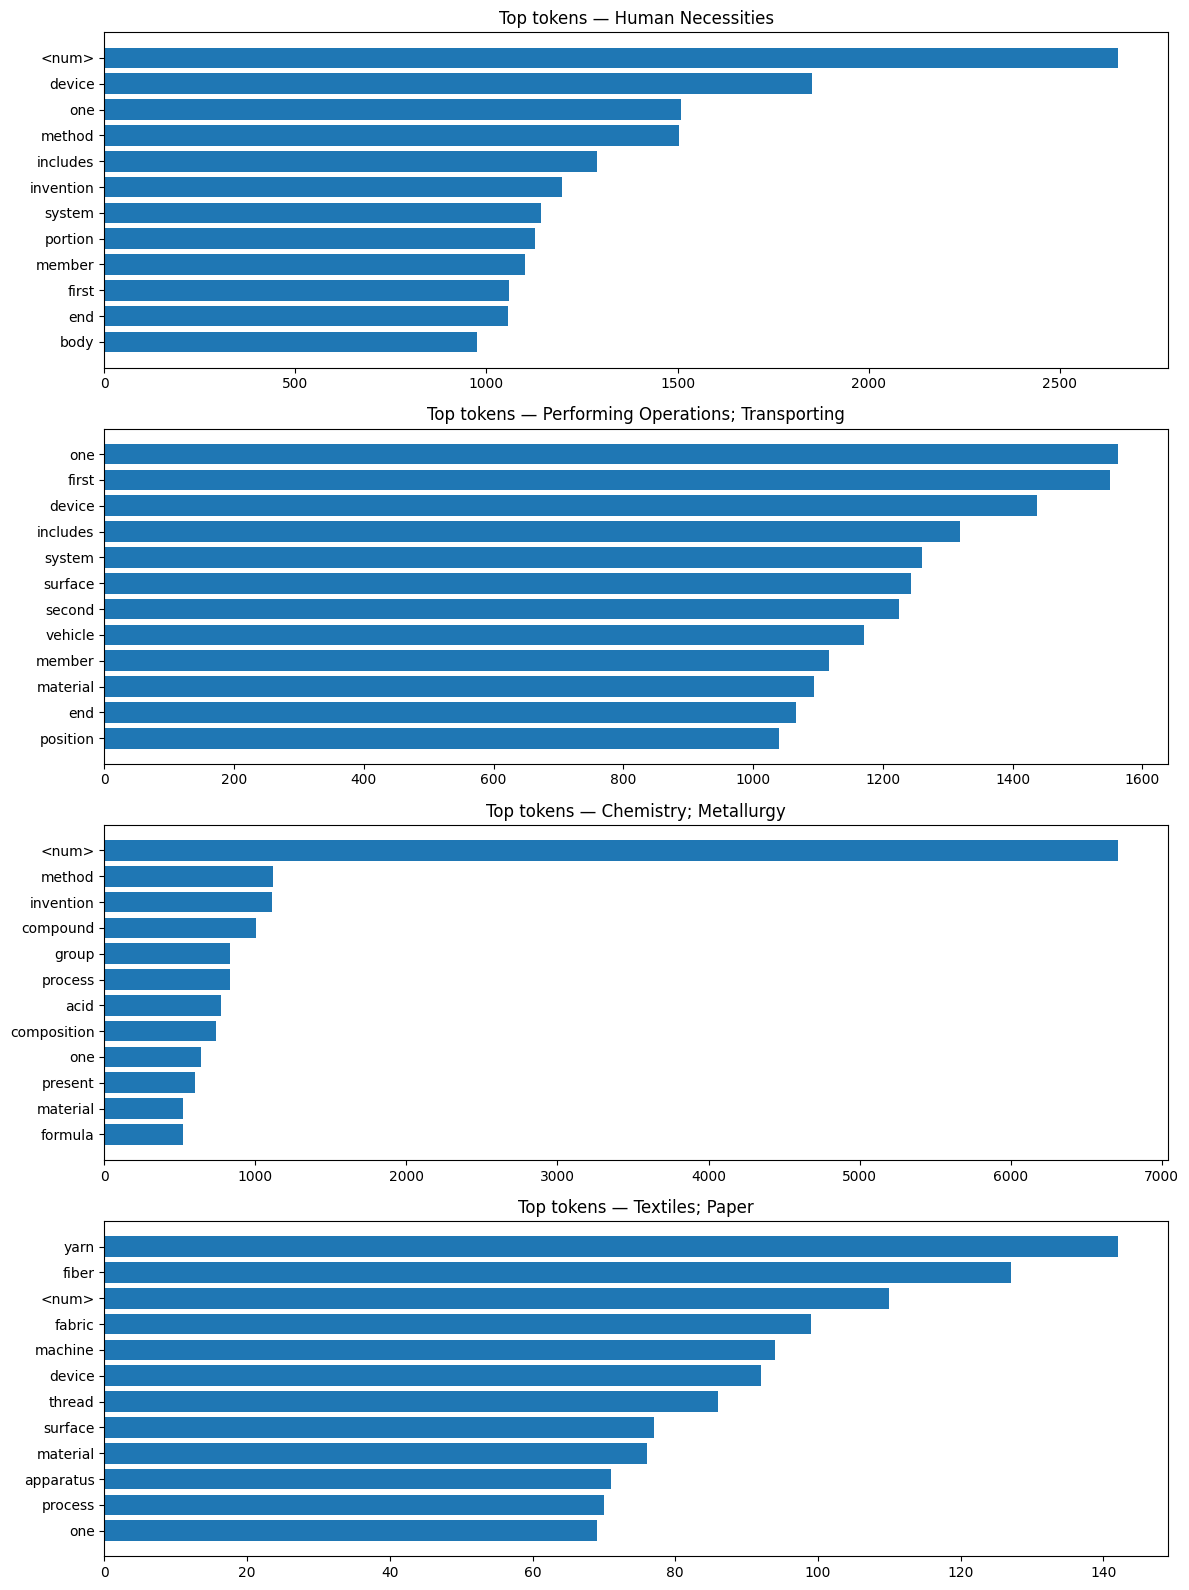

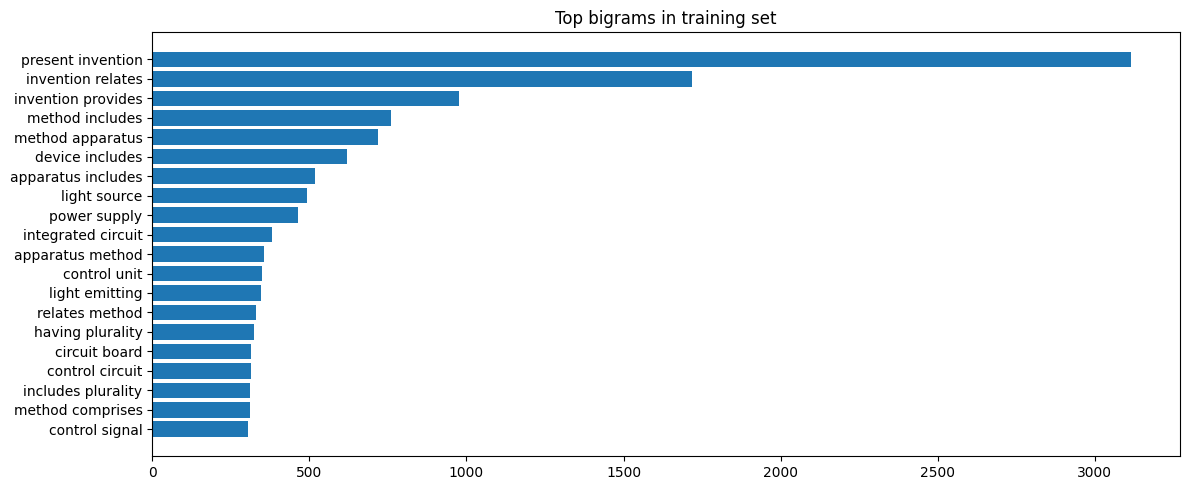

In [21]:
def to_dataframe(split_name):
    df = pd.DataFrame(ds[split_name])
    df["label_name"] = df[LABEL_COL].map(lambda x: label_names[int(x)] if isinstance(x, (int, np.integer)) else str(x))
    df["char_len"] = df[TEXT_COL].astype(str).apply(len)
    df["word_len"] = df[TEXT_COL].astype(str).apply(lambda x: len(str(x).split()))
    df["split"] = split_name
    return df



df_train = to_dataframe("train")
df_val = to_dataframe("validation") if "validation" in ds else to_dataframe("test")
df_test = to_dataframe("test")

df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)

display(df_train.head(3))
print(df_train.shape, df_val.shape, df_test.shape)

# Label distribution
# Đếm số lượng label
label_counts = df_train["label_name"].value_counts().reindex(label_names)

# Wrap label dài thành nhiều dòng
labels = ['\n'.join(textwrap.wrap(label, 20)) for label in label_counts.index]

# Tạo figure
fig, ax = plt.subplots(figsize=(13, 7))

# Vẽ bar với độ rộng nhỏ hơn để tạo khoảng cách
ax.bar(range(len(label_counts)), label_counts.values, width=0.6)

# Set ticks + labels
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9)

# Tăng khoảng cách 2 bên
ax.margins(x=0.1)

# Title + label
ax.set_title("Training label distribution", fontsize=14)
ax.set_ylabel("Count", fontsize=12)

# Grid nhẹ (nhìn giống paper hơn)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Tight layout để tránh cắt chữ
plt.tight_layout()

# Save ảnh
plt.savefig(os.path.join(FIG_DIR, "label_distribution_train.png"), dpi=200)

# Show
plt.show()

# Length distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df_train["word_len"], bins=50)
axes[0].set_title("Training text length (words)")
axes[0].set_xlabel("Words")
axes[0].set_ylabel("Count")

axes[1].hist(df_train["char_len"], bins=50)
axes[1].set_title("Training text length (characters)")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "length_distributions.png"), dpi=200)
plt.show()

# Chuẩn bị data
data = [df_train.loc[df_train["label_name"] == lab, "word_len"].values for lab in label_names]

# Wrap label dài
labels = ['\n'.join(textwrap.wrap(lab, 20)) for lab in label_names]

# Plot
fig, ax = plt.subplots(figsize=(13, 7))

bp = ax.boxplot(
    data,
    labels=labels,
    showfliers=False,
    patch_artist=True  # để tô màu
)

# Tô màu nhẹ (nhìn giống paper hơn)
for box in bp['boxes']:
    box.set(alpha=0.6)

# Title + label
ax.set_title("Word length by class", fontsize=14)
ax.set_ylabel("Words", fontsize=12)

# Giảm font + tránh dính
ax.tick_params(axis="x", labelsize=9)

# Grid nhẹ
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Layout
plt.tight_layout()

# Save
plt.savefig(os.path.join(FIG_DIR, "word_length_by_class.png"), dpi=200)

plt.show()

# sample examples
sample_per_class = 2
sample_rows = []
for lab in label_names:
    sub = df_train[df_train["label_name"] == lab].sample(n=min(sample_per_class, sum(df_train["label_name"] == lab)), random_state=SEED)
    sample_rows.append(sub[[TEXT_COL, "label_name"]])
sample_df = pd.concat(sample_rows, ignore_index=True)
display(sample_df)

# word frequency helpers
def simple_tokenize(text):
    return re.findall(r"[a-z0-9]+", str(text).lower())

def top_tokens_for_class(df, label_name, top_k=20, min_len=3):
    tokens = []
    texts = df.loc[df["label_name"] == label_name, TEXT_COL].astype(str).tolist()
    for t in texts:
        toks = [tok for tok in tokenize_simple(t) if len(tok) >= min_len]
        tokens.extend(toks)
    cnt = Counter(tokens)
    return cnt.most_common(top_k)

def plot_top_tokens_by_class(df, classes, top_k=15):
    n = len(classes)
    fig, axes = plt.subplots(n, 1, figsize=(12, 4 * n))
    if n == 1:
        axes = [axes]
    for ax, lab in zip(axes, classes):
        pairs = top_tokens_for_class(df, lab, top_k=top_k)
        if not pairs:
            continue
        words, vals = zip(*pairs)
        ax.barh(words[::-1], vals[::-1])
        ax.set_title(f"Top tokens — {lab}")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "top_tokens_by_class.png"), dpi=200)
    plt.show()

# Plot a few classes only to keep the notebook readable
plot_top_tokens_by_class(df_train, label_names[:min(4, len(label_names))], top_k=12)

# Top bigrams across the full train set
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_ngrams(texts, ngram_range=(2, 2), top_k=20, title="Top n-grams"):
    vect = CountVectorizer(stop_words="english", ngram_range=ngram_range, min_df=3)
    X = vect.fit_transform(texts.astype(str))
    freqs = np.asarray(X.sum(axis=0)).ravel()
    idx = np.argsort(freqs)[::-1][:top_k]
    terms = np.array(vect.get_feature_names_out())[idx]
    vals = freqs[idx]
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh(terms[::-1], vals[::-1])
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "top_bigrams_train.png"), dpi=200)
    plt.show()

plot_top_ngrams(df_train[TEXT_COL], ngram_range=(2, 2), top_k=20, title="Top bigrams in training set")

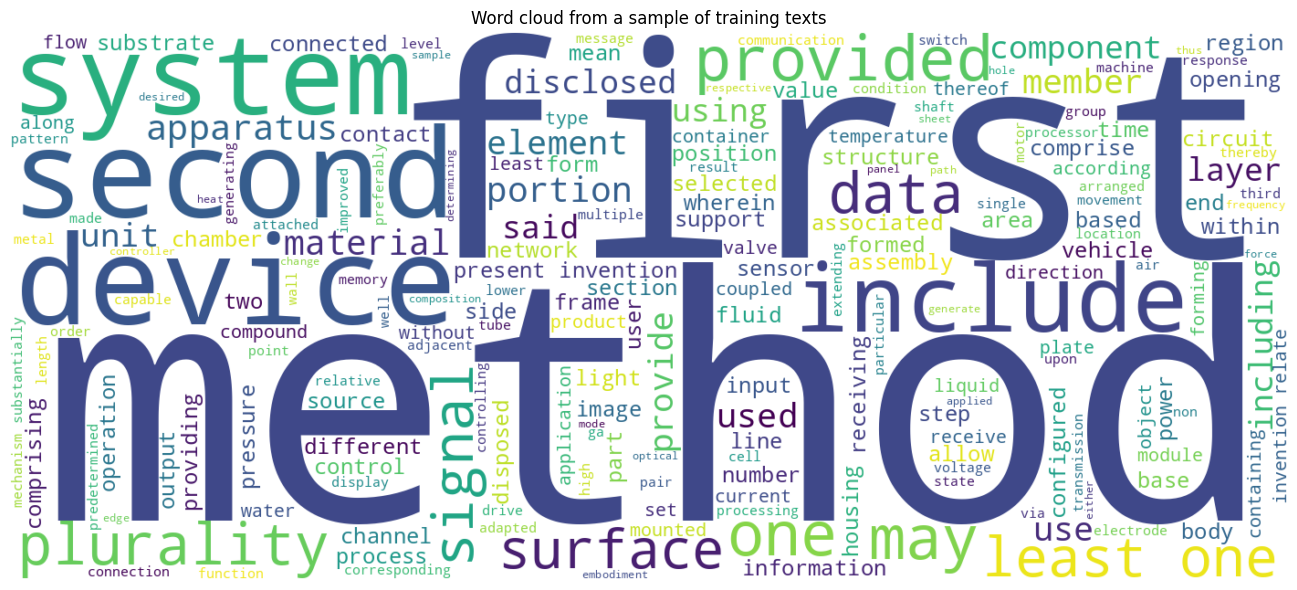

In [22]:
# Optional word cloud (if installed)
try:
    from wordcloud import WordCloud
    text_blob = " ".join(df_train[TEXT_COL].astype(str).sample(min(5000, len(df_train)), random_state=SEED).tolist())
    wc = WordCloud(width=1400, height=600, background_color="white", max_words=200).generate(text_blob)
    plt.figure(figsize=(14, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word cloud from a sample of training texts")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "wordcloud_train.png"), dpi=200)
    plt.show()
except Exception as e:
    print("WordCloud is optional and not available:", e)

In [23]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(df_train[LABEL_COL])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=df_train[LABEL_COL]
)

class_weights = torch.tensor(weights, dtype=torch.float).to(DEVICE)


def get_num_params(model):
    return sum(p.numel() for p in model.parameters())

def format_seconds(seconds):
    if seconds < 60:
        return f"{seconds:.2f}s"
    return f"{seconds/60:.2f}m"

def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "macro_precision": precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)[0],
        "macro_recall": precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)[1],
        "weighted_precision": precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)[0],
        "weighted_recall": precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)[1],
    }

def plot_history(history, title, save_name=None):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history["train_loss"], label="train")
    axes[0].plot(history["val_loss"], label="val")
    axes[0].set_title(f"{title} — Loss")
    axes[0].legend()

    axes[1].plot(history["train_acc"], label="train")
    axes[1].plot(history["val_acc"], label="val")
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].legend()

    plt.tight_layout()
    if save_name:
        plt.savefig(os.path.join(FIG_DIR, save_name), dpi=200)
    plt.show()

def plot_confusion_matrix(y_true, y_pred, labels, title, save_name=None, normalize=False):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]:.2f}" if normalize else f"{int(cm[i, j])}",
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=8)
    ax.set_ylabel("True")
    ax.set_xlabel("Pred")
    plt.tight_layout()
    if save_name:
        plt.savefig(os.path.join(FIG_DIR, save_name), dpi=200)
    plt.show()


def plot_per_class_f1(y_true, y_pred, labels, title="Per-class F1", save_name=None):
    rep = classification_report(y_true, y_pred, target_names=labels, output_dict=True, zero_division=0)
    f1s = [rep[l]["f1-score"] for l in labels]
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(labels, f1s)
    ax.set_title(title)
    ax.set_ylabel("F1")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    if save_name:
        plt.savefig(os.path.join(FIG_DIR, save_name), dpi=200)
    plt.show()


def top_confused_pairs(y_true, y_pred, labels, top_k=10):
    cm = confusion_matrix(y_true, y_pred)
    pairs = []
    for i in range(len(labels)):
        for j in range(len(labels)):
            if i != j and cm[i, j] > 0:
                pairs.append((labels[i], labels[j], int(cm[i, j])))
    pairs.sort(key=lambda x: x[2], reverse=True)
    return pd.DataFrame(pairs[:top_k], columns=["true_label", "pred_label", "count"])

def build_results_df(results):
    rows = []
    for r in results:
        row = {
            "name": r["name"],
            "family": r["family"],
            "params": r.get("params", None),
            "train_time_sec": r.get("train_time_sec", None),
            "val_acc": r.get("val_acc", None),
            "val_weighted_f1": r.get("val_weighted_f1", None),
            "test_acc": r.get("test_acc", None),
            "test_weighted_f1": r.get("test_weighted_f1", None),
        }
        rows.append(row)
    return pd.DataFrame(rows)

def save_classification_report(y_true, y_pred, labels, path):
    rep = classification_report(y_true, y_pred, target_names=labels, zero_division=0)
    with open(path, "w", encoding="utf-8") as f:
        f.write(rep)
    return rep

def show_misclassified_examples(df, y_true, y_pred, probs=None, n=10):
    errors = []
    for idx, (t, p) in enumerate(zip(y_true, y_pred)):
        if int(t) != int(p):
            conf = float(probs[idx, p]) if probs is not None else None
            errors.append({
                "index": idx,
                "text": str(df.iloc[idx][TEXT_COL])[:500],
                "true_label": label_names[int(t)],
                "pred_label": label_names[int(p)],
                "confidence": conf,
            })
    err_df = pd.DataFrame(errors)
    if len(err_df) == 0:
        print("No errors found.")
        return err_df
    display(err_df.head(n))
    return err_df

In [24]:
# from transformers import MarianMTModel, MarianTokenizer

# # =========================
# # CONFIG
# # =========================
# TEXT_COL = "text"
# LABEL_COL = "label_name"

# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# BATCH_SIZE = 32 if DEVICE == "cuda" else 8
# MAX_LENGTH = 350

# # 🔥 MAIN CONFIG (bạn chọn)
# PIVOTS = ["fr", "de", "es"]
# AUG_PER_SAMPLE = 2
# AUG_CAP_MULTIPLIER = 4
# TARGET_MODE = "p75"

# # sampling
# TOP_P = 0.9
# TEMP = 0.7

# SEED = 42
# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)

# # =========================
# # LOAD MODELS
# # =========================
# def load_pair(src, tgt):
#     name = f"Helsinki-NLP/opus-mt-{src}-{tgt}"
#     tok = MarianTokenizer.from_pretrained(name)
#     model = MarianMTModel.from_pretrained(name).to(DEVICE)
#     model.eval()
#     if DEVICE == "cuda":
#         model = model.half()
#     return tok, model

# pairs = []
# for mid in PIVOTS:
#     tok1, m1 = load_pair("en", mid)
#     tok2, m2 = load_pair(mid, "en")
#     pairs.append(((tok1, m1), (tok2, m2)))

# # =========================
# # TRANSLATION
# # =========================
# def translate_batch(texts, tokenizer, model):
#     inputs = tokenizer(
#         texts,
#         return_tensors="pt",
#         padding=True,
#         truncation=True,
#         max_length=MAX_LENGTH
#     ).to(DEVICE)

#     with torch.inference_mode():
#         if DEVICE == "cuda":
#             with torch.autocast("cuda"):
#                 outputs = model.generate(
#                     **inputs,
#                     do_sample=True,
#                     top_p=TOP_P,
#                     temperature=TEMP,
#                     num_beams=1,
#                     max_new_tokens=MAX_LENGTH
#                 )
#         else:
#             outputs = model.generate(
#                 **inputs,
#                 do_sample=True,
#                 top_p=TOP_P,
#                 temperature=TEMP,
#                 num_beams=1,
#                 max_new_tokens=MAX_LENGTH
#             )

#     return tokenizer.batch_decode(outputs, skip_special_tokens=True)

# # =========================
# # BACK TRANSLATION (FAST)
# # =========================
# def back_translate_batch(texts):
#     all_variants = [[] for _ in texts]

#     for _ in range(AUG_PER_SAMPLE):
#         pivot_idx = random.randrange(len(pairs))
#         (tok_a, m_a), (tok_b, m_b) = pairs[pivot_idx]

#         mid = translate_batch(texts, tok_a, m_a)
#         back = translate_batch(mid, tok_b, m_b)

#         for i, bt in enumerate(back):
#             if isinstance(bt, str) and len(bt.split()) >= 3:
#                 all_variants[i].append(bt)

#     return all_variants

# # =========================
# # TARGET COUNT
# # =========================
# def get_target(counts):
#     vals = counts.values
#     if TARGET_MODE == "median":
#         return int(np.median(vals))
#     elif TARGET_MODE == "p75":
#         return int(np.percentile(vals, 75))
#     else:
#         return int(np.mean(vals))

# # =========================
# # BUILD AUGMENTED DATA
# # =========================
# def build_augmented(df):
#     df = df.copy()
#     counts = df[LABEL_COL].value_counts()
#     target = get_target(counts)

#     augmented = []

#     for label, n in counts.items():
#         df_cls = df[df[LABEL_COL] == label]

#         need = max(0, target - n)
#         cap = int(n * (AUG_CAP_MULTIPLIER - 1))
#         n_to_add = min(need, cap)

#         if n_to_add <= 0:
#             continue

#         samples = df_cls.sample(n=n_to_add, replace=True)[TEXT_COL].astype(str).tolist()

#         for i in tqdm(range(0, len(samples), BATCH_SIZE), desc=f"Augmenting {label[:20]}"):
#             batch = samples[i:i+BATCH_SIZE]
#             variants_batch = back_translate_batch(batch)

#             for orig, variants in zip(batch, variants_batch):
#                 for aug in set(variants):  # remove duplicates
#                     orig_len = len(orig.split())
#                     aug_len = len(aug.split())

#                     if aug_len < 3:
#                         continue

#                     ratio = aug_len / (orig_len + 1e-6)

#                     if ratio < 0.5 or ratio > 1.5:
#                         continue
#                     augmented.append({
#                         TEXT_COL: aug,
#                         LABEL_COL: label
#                     })

#     df_aug = pd.DataFrame(augmented)
#     df_aug["char_len"] = df_aug["text"].astype(str).apply(len)
    
#     df_aug["word_len"] = df_aug["text"].astype(str).apply(lambda x: len(x.split()))
#     df_aug["label"] = df_aug["label_name"].map(label2id)
#     # đảm bảo đúng split
#     df_aug["split"] = "train"

#     # remove duplicates globally
#     df_final = pd.concat([df, df_aug], ignore_index=True)
#     df_final = df_final.drop_duplicates(subset=[TEXT_COL])

#     return df_final, df_aug

# # =========================
# # RUN
# # =========================
# df_train, df_added = build_augmented(df_train)

# print("Original size:", len(df_train))
# print("Augmented added:", len(df_added))
# print("Final size:", len(df_train_aug))

# df_train.to_csv("train_augmented_strong.csv", index=False)
# print("Saved to train_augmented_strong.csv")

In [25]:
import gdown

file_id = "1mQ2gpT_eFSNYvCsIFQRLojMlSmWpb_Fn"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "train_augmented_strong.csv", quiet=False)
df_train = pd.read_csv("train_augmented_strong.csv")

Downloading...
From: https://drive.google.com/uc?id=1mQ2gpT_eFSNYvCsIFQRLojMlSmWpb_Fn
To: /kaggle/working/train_augmented_strong.csv
100%|██████████| 27.2M/27.2M [00:00<00:00, 167MB/s]


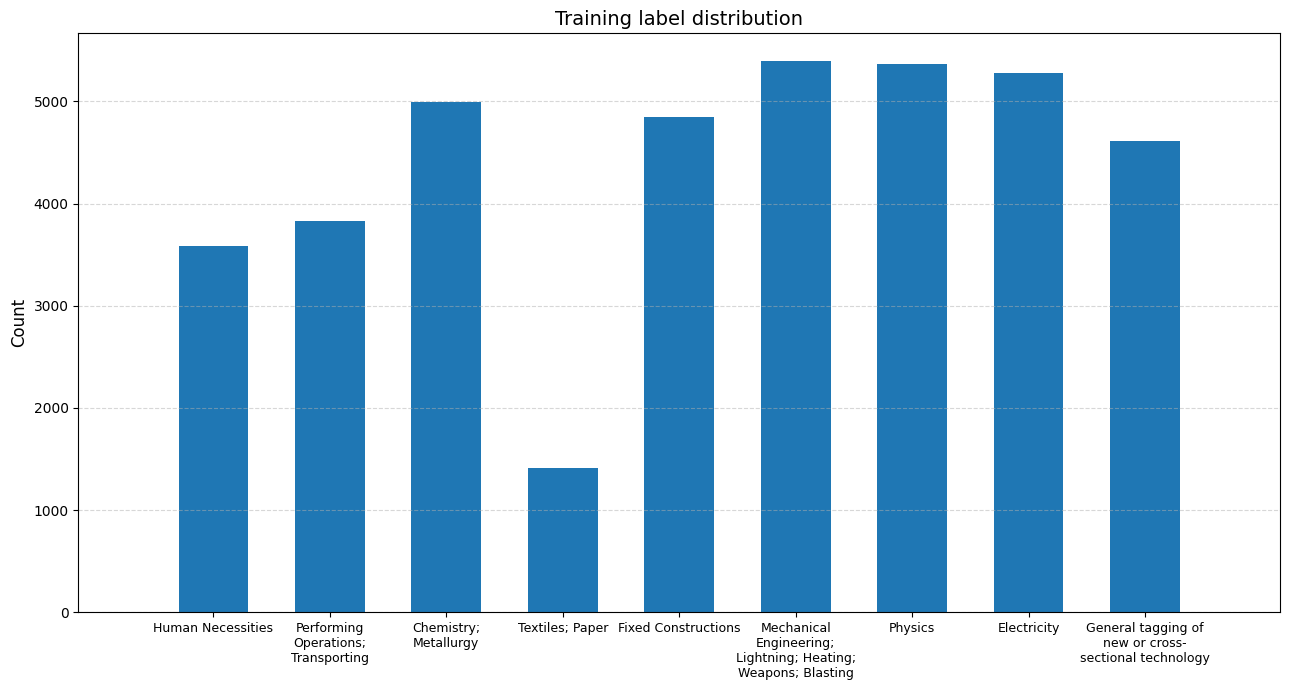

In [26]:
# Label distribution
# Đếm số lượng label
label_counts = df_train["label_name"].value_counts().reindex(label_names)

# Wrap label dài thành nhiều dòng
labels = ['\n'.join(textwrap.wrap(label, 20)) for label in label_counts.index]

# Tạo figure
fig, ax = plt.subplots(figsize=(13, 7))

# Vẽ bar với độ rộng nhỏ hơn để tạo khoảng cách
ax.bar(range(len(label_counts)), label_counts.values, width=0.6)

# Set ticks + labels
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9)

# Tăng khoảng cách 2 bên
ax.margins(x=0.1)

# Title + label
ax.set_title("Training label distribution", fontsize=14)
ax.set_ylabel("Count", fontsize=12)

# Grid nhẹ (nhìn giống paper hơn)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Tight layout để tránh cắt chữ
plt.tight_layout()

# Save ảnh
plt.savefig(os.path.join(FIG_DIR, "label_distribution_train.png"), dpi=200)

# Show
plt.show()

In [ ]:
# =========================
# 4. BUILD VOCAB
# =========================
def build_vocab(texts, max_vocab=40000, min_freq=2):
    counter = Counter()
    for text in texts:
        counter.update(tokenize_simple(text))

    specials = ["<pad>", "<unk>", "<bos>", "<eos>", "<num>"]
    vocab = specials[:]

    for tok, freq in counter.most_common():
        if freq < min_freq:
            continue
        if tok not in vocab:
            vocab.append(tok)
        if len(vocab) >= max_vocab:
            break

    stoi = {tok: idx for idx, tok in enumerate(vocab)}
    itos = vocab
    return stoi, itos

token_to_id, id_to_token = build_vocab(
    df_train[TEXT_COL].astype(str).tolist(),
    max_vocab=RNN_MAX_VOCAB,
    min_freq=1
)

PAD_ID = token_to_id["<pad>"]
UNK_ID = token_to_id["<unk>"]
BOS_ID = token_to_id["<bos>"]
EOS_ID = token_to_id["<eos>"]

print("Vocab size:", len(token_to_id))

# =========================
# 5. ENCODE
# =========================
def encode_text(text, max_len=350):
    tokens = tokenize_simple(text)
    tokens = ["<bos>"] + tokens + ["<eos>"]

    ids = [token_to_id[tok] for tok in tokens[:max_len] if tok in token_to_id]

    # fallback nếu bị rỗng
    if len(ids) == 0:
        ids = [UNK_ID]

    length = len(ids)

    if length < max_len:
        ids += [PAD_ID] * (max_len - length)

    return ids, length

# =========================
# 6. AUGMENTATION (OPTIONAL)
# =========================
def word_dropout(text, p=0.08):
    tokens = tokenize_simple(text)
    if len(tokens) <= 3:
        return text
    kept = [t for t in tokens if random.random() > p]
    if len(kept) < 3:
        kept = tokens[:3]
    return " ".join(kept)

# =========================
# 7. DATASET
# =========================
LABEL_COL= "label"
class RNNDataset(Dataset):
    def __init__(self, df, max_len=350, augment_fn=None):
        self.df = df.reset_index(drop=True)
        self.max_len = max_len
        self.augment_fn = augment_fn

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        text = str(self.df.loc[idx, TEXT_COL])
        label = int(self.df.loc[idx, LABEL_COL])

        if self.augment_fn is not None:
            text = self.augment_fn(text)

        ids, length = encode_text(text, self.max_len)

        return {
            "input_ids": torch.tensor(ids, dtype=torch.long),
            "length": torch.tensor(length, dtype=torch.long),
            "labels": torch.tensor(label, dtype=torch.long),
        }

# =========================
# 8. BUILD EMBEDDING MATRIX (GloVe)
# =========================
def build_embedding_matrix(word2idx, embedding_dim=300, use_pretrained=True):
    vocab_size = len(word2idx)

    matrix = np.random.normal(0, 0.02, (vocab_size, embedding_dim)).astype(np.float32)
    matrix[word2idx["<pad>"]] = np.zeros(embedding_dim, dtype=np.float32)

    if not use_pretrained:
        return matrix, 0.0

    try:
        import gensim.downloader as api
        model = api.load("fasttext-wiki-news-subwords-300")

        found = 0
        for word, idx in word2idx.items():
            if word in model:
                matrix[idx] = model[word]
                found += 1

        coverage = found / vocab_size
        print(f"FastText coverage: {coverage:.3f}")

        return matrix, coverage

    except Exception as e:
        print("Fallback random embedding")
        print("Reason:", e)
        return matrix, 0.0

# =========================
# 9. LOAD EMBEDDING
# =========================
PRETRAINED_EMB_DIM = 300

embedding_matrix, coverage = build_embedding_matrix(
    token_to_id,
    embedding_dim=PRETRAINED_EMB_DIM,
    use_pretrained=True
)

print("Embedding shape:", embedding_matrix.shape)

# =========================
# DONE
# =========================

Vocab size: 37866


In [ ]:
def make_rnn_loaders(augment_fn=None, batch_size=RNN_BATCH_SIZE, max_len=RNN_MAX_LEN):
    train_ds = RNNDataset(df_train, max_len=max_len, augment_fn=augment_fn)
    val_ds = RNNDataset(df_val, max_len=max_len, augment_fn=None)
    test_ds = RNNDataset(df_test, max_len=max_len, augment_fn=None)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=4)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=4)
    return train_loader, val_loader, test_loader

def masked_mean_pooling(outputs, mask):
    mask = mask.unsqueeze(-1).float()
    summed = (outputs * mask).sum(dim=1)
    denom = mask.sum(dim=1).clamp(min=1e-6)
    return summed / denom

class AttentionPooling(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.proj = nn.Linear(hidden_size, hidden_size)
        self.score = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, outputs, mask):
        scores = self.score(torch.tanh(self.proj(outputs))).squeeze(-1)
        scores = scores.masked_fill(mask == 0, -1e4)
        weights = torch.softmax(scores, dim=1)
        context = torch.bmm(weights.unsqueeze(1), outputs).squeeze(1)
        return context, weights

class RNNTextClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        num_classes,
        pad_idx,
        rnn_type="lstm",            # "rnn", "lstm", "gru"
        bidirectional=False,
        num_layers=1,
        dropout=0.3,
        use_attention=False,
        embedding_matrix=None,
        freeze_embedding=False,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(torch.tensor(embedding_matrix))
        self.embedding.weight.requires_grad = not freeze_embedding

        self.rnn_type = rnn_type.lower()
        self.use_attention = use_attention
        self.bidirectional = bidirectional
        rnn_dropout = dropout if num_layers > 1 else 0.0

        if self.rnn_type == "lstm":
            self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=rnn_dropout, bidirectional=bidirectional)
        elif self.rnn_type == "gru":
            self.rnn = nn.GRU(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=rnn_dropout, bidirectional=bidirectional)
        elif self.rnn_type == "rnn":
            self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers=num_layers, nonlinearity="tanh", batch_first=True, dropout=rnn_dropout, bidirectional=bidirectional)
        else:
            raise ValueError(f"Unknown rnn_type: {rnn_type}")

        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.dropout = nn.Dropout(dropout)
        self.attention = AttentionPooling(out_dim) if use_attention else None
        self.classifier = nn.Linear(out_dim, num_classes)

    def forward(self, input_ids, lengths):
        # input_ids: (B, T), lengths: (B,)
        emb = self.embedding(input_ids)
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.rnn(packed)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
        # outputs: (B, T, H)
        max_t = outputs.size(1)
        mask = torch.arange(max_t, device=lengths.device).unsqueeze(0) < lengths.unsqueeze(1)

        if self.use_attention:
            rep, attn = self.attention(outputs, mask)
        else:
            rep = masked_mean_pooling(outputs, mask)
            attn = None

        rep = self.dropout(rep)
        logits = self.classifier(rep)
        return logits, attn

In [ ]:
def batch_to_device(batch, device):
    out = {}
    for k, v in batch.items():
        out[k] = v.to(device)
    return out

def eval_rnn(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    preds, trues = [], []
    all_probs = []
    with torch.no_grad():
        for batch in loader:
            batch = batch_to_device(batch, DEVICE)
            logits, _ = model(batch["input_ids"], batch["length"])
            loss = criterion(logits, batch["labels"])
            total_loss += loss.item() * len(batch["labels"])
            prob = torch.softmax(logits, dim=-1)
            pred = prob.argmax(dim=1)
            preds.extend(pred.cpu().numpy().tolist())
            trues.extend(batch["labels"].cpu().numpy().tolist())
            all_probs.append(prob.cpu().numpy())
    all_probs = np.concatenate(all_probs, axis=0) if len(all_probs) else None
    metrics = compute_metrics(trues, preds)
    metrics["loss"] = total_loss / max(len(loader.dataset), 1)
    return metrics, np.array(trues), np.array(preds), all_probs

def train_rnn(model, train_loader, val_loader, test_loader, epochs=4, lr=1e-3, weight_decay=1e-3, grad_clip=1.0, patience=3, name="rnn_model"):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    # criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay)
    total_steps = len(train_loader) * epochs
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(total_steps, 1))

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "train_weighted_f1": [], "val_weighted_f1": []}
    best_state = None
    best_val_f1 = -1
    no_improve = 0
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        trues, preds = [], []
        for batch in train_loader:
            batch = batch_to_device(batch, DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits, _ = model(batch["input_ids"], batch["length"])
            loss = criterion(logits, batch["labels"])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            scheduler.step()

            total_loss += loss.item() * len(batch["labels"])
            pred = logits.argmax(dim=1)
            trues.extend(batch["labels"].detach().cpu().numpy().tolist())
            preds.extend(pred.detach().cpu().numpy().tolist())

        train_metrics = compute_metrics(trues, preds)
        train_metrics["loss"] = total_loss / max(len(train_loader.dataset), 1)

        val_metrics, _, _, _ = eval_rnn(model, val_loader, criterion)
        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["train_acc"].append(train_metrics["accuracy"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["train_weighted_f1"].append(train_metrics["weighted_f1"])
        history["val_weighted_f1"].append(val_metrics["weighted_f1"])
        history["train_weighted_f1"].append(train_metrics["weighted_f1"])
        history["val_weighted_f1"].append(val_metrics["weighted_f1"])

        print(
            f"[{name}] Epoch {epoch}/{epochs} | "
            f"train loss {train_metrics['loss']:.4f} acc {train_metrics['accuracy']:.4f} | "
            f"val loss {val_metrics['loss']:.4f} acc {val_metrics['accuracy']:.4f} f1 {val_metrics['weighted_f1']:.4f}"
        )

        if val_metrics["weighted_f1"] > best_val_f1:
            best_val_f1 = val_metrics["weighted_f1"]
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
            torch.save(best_state, os.path.join(CKPT_DIR, f"{name}.pt"))
        else:
            no_improve += 1
            if no_improve >= patience:
                print("Early stopping triggered.")
                break

    elapsed = time.time() - t0
    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics, y_true, y_pred, probs = eval_rnn(model, test_loader, criterion)
    result = {
        "name": name,
        "family": "RNN",
        "model": model,
        "history": history,
        "params": get_num_params(model),
        "train_time_sec": elapsed,
        "val_acc": max(history["val_acc"]) if history["val_acc"] else None,
        "val_weighted_f1": max([m for m in history["val_acc"]]) if history["val_acc"] else None,
        "test_acc": test_metrics["accuracy"],
        "test_weighted_f1": test_metrics["weighted_f1"],
        "y_true": y_true,
        "y_pred": y_pred,
        "probs": probs,
        "test_metrics": test_metrics,
    }
    return result

In [ ]:
def random_word_dropout(text, p=0.05):
    toks = simple_tokenize(text)
    if len(toks) <= 3:
        return text
    kept = [t for t in toks if random.random() > p]
    return " ".join(kept) if kept else text

def random_token_swap(text, swap_prob=0.05):
    toks = simple_tokenize(text)
    toks = toks[:]
    for i in range(len(toks) - 1):
        if random.random() < swap_prob:
            toks[i], toks[i + 1] = toks[i + 1], toks[i]
    return " ".join(toks) if toks else text

def synonym_replacement_optional(text, replace_prob=0.05):
    # Optional: uses WordNet if available. Falls back to original text otherwise.
    try:
        import nltk
        from nltk.corpus import wordnet as wn
    except Exception:
        return text

    toks = simple_tokenize(text)
    out = []
    for tok in toks:
        if random.random() < replace_prob:
            syns = wn.synsets(tok)
            lemmas = []
            for syn in syns[:3]:
                lemmas.extend([l.name().replace("_", " ") for l in syn.lemmas()[:3]])
            lemmas = [l for l in lemmas if l.lower() != tok.lower()]
            out.append(random.choice(lemmas) if lemmas else tok)
        else:
            out.append(tok)
    return " ".join(out) if out else text

def compose_augmentations(text):
    text = random_word_dropout(text, p=0.03)
    text = random_token_swap(text, swap_prob=0.03)
    return text

In [ ]:
# Pretrained embedding variants will be reused across several experiments.
rnn_train_loader, rnn_val_loader, rnn_test_loader = make_rnn_loaders(batch_size=RNN_BATCH_SIZE, max_len=RNN_MAX_LEN)

rnn_experiments = [
    dict(name="rnn_lstm_random", rnn_type="lstm", bidirectional=False, use_attention=False, embedding_matrix=None, freeze_embedding=False, hidden_dim=256, embed_dim=300, lr=1e-3),
    dict(name="rnn_gru_random", rnn_type="gru", bidirectional=False, use_attention=False, embedding_matrix=None, freeze_embedding=False, hidden_dim=256, embed_dim=300, lr=1e-3),
    dict(name="rnn_bilstm_glove_frozen", rnn_type="lstm", bidirectional=True, use_attention=False, embedding_matrix=embedding_matrix, freeze_embedding=True, hidden_dim=256, embed_dim=PRETRAINED_EMB_DIM, lr=1e-3),
    dict(name="rnn_bigru_glove_trainable", rnn_type="gru", bidirectional=True, use_attention=False, embedding_matrix=embedding_matrix, freeze_embedding=False, hidden_dim=256, embed_dim=PRETRAINED_EMB_DIM, lr=1e-3),
    dict(name="rnn_bilstm_attention_glove", rnn_type="lstm", bidirectional=True, use_attention=True, embedding_matrix=embedding_matrix, freeze_embedding=False, hidden_dim=256, embed_dim=PRETRAINED_EMB_DIM, lr=1e-3),
]

rnn_results = []
if RUN_ALL_EXPERIMENTS:
    for cfg in rnn_experiments:
        model = RNNTextClassifier(
            vocab_size=len(token_to_id),
            embed_dim=cfg["embed_dim"],
            hidden_dim=cfg["hidden_dim"],
            num_classes=num_labels,
            pad_idx=PAD_ID,
            rnn_type=cfg["rnn_type"],
            bidirectional=cfg["bidirectional"],
            num_layers=1,
            dropout=0.5,
            use_attention=cfg["use_attention"],
            embedding_matrix=cfg["embedding_matrix"],
            freeze_embedding=cfg["freeze_embedding"],
        )
        print(f"Training {cfg['name']} | params={get_num_params(model):,}")
        res = train_rnn(
            model,
            rnn_train_loader,
            rnn_val_loader,
            rnn_test_loader,
            epochs=10,
            lr=cfg["lr"],
            name=cfg["name"],
        )
        res["config"] = cfg
        rnn_results.append(res)

        plot_history(res["history"], title=cfg["name"], save_name=f"{cfg['name']}_history.png")

rnn_results_df = pd.DataFrame([{
    "name": r["name"],
    "family": r["family"],
    "params": r["params"],
    "train_time_sec": r["train_time_sec"],
    "test_acc": r["test_acc"],
    "test_weighted_f1": r["test_weighted_f1"],
} for r in rnn_results])

display(rnn_results_df.sort_values("test_weighted_f1", ascending=False))

In [ ]:
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

TRANSFORMER_MODELS = {
    "distilbert": "distilbert-base-uncased",
    "bert": "bert-base-uncased",
    "roberta": "roberta-base",
}

def clean_text_light(text):
    text = str(text)
    text = html.unescape(text)
    text = unicodedata.normalize("NFKC", text)

    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)

    text = re.sub(r"\s+", " ", text).strip()
    return text

class TransformerTextDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=256, augment_fn=None):
        self.labels = df[LABEL_COL].astype(int).values
        raw_texts = df[TEXT_COL].astype(str).tolist()
        self.augment_fn = augment_fn

        # ⚡ Clean + augment (nếu có)
        processed_texts = []
        for text in raw_texts:
            text = clean_text_light(text)
            processed_texts.append(text)

        # ⚡ Tokenize 1 lần duy nhất
        self.encodings = tokenizer(
            processed_texts,
            truncation=True,
            padding=False,
            max_length=max_len,
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item    

def make_transformer_loaders(tokenizer, batch_size=8, max_len=256, augment_fn=None):

    data_collator = DataCollatorWithPadding(tokenizer)
    train_ds = TransformerTextDataset(df_train, tokenizer, max_len=max_len, augment_fn=augment_fn)
    val_ds = TransformerTextDataset(df_val, tokenizer, max_len=max_len, augment_fn=None)
    test_ds = TransformerTextDataset(df_test, tokenizer, max_len=max_len, augment_fn=None)
    train_loader = DataLoader(train_ds,collate_fn=data_collator, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_ds,collate_fn=data_collator, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_ds,collate_fn=data_collator, batch_size=batch_size, shuffle=False, num_workers=4,pin_memory=True)
    return train_loader, val_loader, test_loader

def masked_mean_pooling_transformer(hidden_states, attention_mask):
    mask = attention_mask.unsqueeze(-1).float()
    summed = (hidden_states * mask).sum(dim=1)
    denom = mask.sum(dim=1).clamp(min=1e-6)
    return summed / denom

class TransformerClassifier(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.1, pooler="cls"):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden_size = self.backbone.config.hidden_size
        self.pooler = pooler
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes),
        )

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        kwargs = {"input_ids": input_ids, "attention_mask": attention_mask}
        if token_type_ids is not None:
            kwargs["token_type_ids"] = token_type_ids
        outputs = self.backbone(**kwargs)
        last_hidden = outputs.last_hidden_state
        if self.pooler == "mean":
            rep = masked_mean_pooling_transformer(last_hidden, attention_mask)
        else:
            rep = last_hidden[:, 0]
        rep = self.dropout(rep)
        logits = self.classifier(rep)
        return logits

class HybridTransformerRNN(nn.Module):
    def __init__(
        self,
        model_name,
        num_classes,
        rnn_type="lstm",
        hidden_dim=256,
        bidirectional=True,
        use_attention=True,
        dropout=0.2,
        pooler="cls",
    ):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        self.pooler = pooler
        self.rnn_type = rnn_type.lower()
        self.use_attention = use_attention
        self.bidirectional = bidirectional

        in_dim = self.backbone.config.hidden_size
        rnn_dropout = dropout if 1 > 1 else 0.0
        if self.rnn_type == "lstm":
            self.rnn = nn.LSTM(in_dim, hidden_dim, batch_first=True, bidirectional=bidirectional)
        elif self.rnn_type == "gru":
            self.rnn = nn.GRU(in_dim, hidden_dim, batch_first=True, bidirectional=bidirectional)
        elif self.rnn_type == "rnn":
            self.rnn = nn.RNN(in_dim, hidden_dim, batch_first=True, nonlinearity="tanh", bidirectional=bidirectional)
        else:
            raise ValueError(f"Unknown rnn_type: {rnn_type}")
        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.attention = AttentionPooling(out_dim) if use_attention else None
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(out_dim, num_classes)

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        kwargs = {"input_ids": input_ids, "attention_mask": attention_mask}
        if token_type_ids is not None:
            kwargs["token_type_ids"] = token_type_ids
        outputs = self.backbone(**kwargs)
        seq = outputs.last_hidden_state
        rnn_out, _ = self.rnn(seq)
        if self.use_attention:
            rep, attn = self.attention(rnn_out, attention_mask)
        else:
            rep = masked_mean_pooling(rnn_out, attention_mask)
            attn = None
        rep = self.dropout(rep)
        logits = self.classifier(rep)
        return logits, attn

def freeze_backbone(model):
    backbone = getattr(model, "backbone", None)
    if backbone is None:
        return
    for p in backbone.parameters():
        p.requires_grad = False

def unfreeze_last_n_transformer_layers(model, n=2):
    backbone = getattr(model, "backbone", None)
    if backbone is None:
        return
    # Try common architectures
    layer_container = None
    if hasattr(backbone, "encoder") and hasattr(backbone.encoder, "layer"):
        layer_container = backbone.encoder.layer
    elif hasattr(backbone, "transformer") and hasattr(backbone.transformer, "layer"):
        layer_container = backbone.transformer.layer
    elif hasattr(backbone, "bert") and hasattr(backbone.bert.encoder, "layer"):
        layer_container = backbone.bert.encoder.layer
    if layer_container is None:
        return
    for layer in layer_container[:-n]:
        for p in layer.parameters():
            p.requires_grad = False
    for layer in layer_container[-n:]:
        for p in layer.parameters():
            p.requires_grad = True

def build_layerwise_optimizer(model, base_lr=2e-5, head_lr=2e-4, weight_decay=0.01, layer_decay=0.9):
    # Simple layer-wise LR for transformer backbones.
    no_decay = ["bias", "LayerNorm.weight", "layer_norm.weight", "norm.weight"]
    param_groups = []
    backbone = getattr(model, "backbone", None)
    if backbone is None:
        return torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=weight_decay)

    named_params = list(model.named_parameters())
    layers = []
    max_layer_idx = -1
    for name, _ in named_params:
        m = re.search(r"(encoder\.layer|transformer\.layer)\.(\d+)", name)
        if m:
            max_layer_idx = max(max_layer_idx, int(m.group(2)))
    # fallback for BERT-like 12 layers or DistilBERT-like 6
    if max_layer_idx < 0:
        max_layer_idx = 11

    def get_layer_id(name):
        if "classifier" in name or "pooler" in name:
            return max_layer_idx + 1
        if "embeddings" in name:
            return 0
        m = re.search(r"(encoder\.layer|transformer\.layer)\.(\d+)", name)
        if m:
            return int(m.group(2)) + 1
        return max_layer_idx + 1

    for name, param in named_params:
        if not param.requires_grad:
            continue
        layer_id = get_layer_id(name)
        lr = head_lr if layer_id == max_layer_idx + 1 else base_lr * (layer_decay ** (max_layer_idx - layer_id + 1))
        wd = 0.0 if any(nd in name for nd in no_decay) else weight_decay
        param_groups.append({"params": [param], "lr": lr, "weight_decay": wd})
    return torch.optim.AdamW(param_groups)

In [ ]:
def eval_transformer(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    preds, trues = [], []
    probs_list = []
    with torch.no_grad():
        for batch in loader:
            labels = batch["labels"].to(DEVICE)
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            token_type_ids = batch.get("token_type_ids")
            if token_type_ids is not None:
                token_type_ids = token_type_ids.to(DEVICE)

            try:
                logits = model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
            except TypeError:
                logits, _ = model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)

            if isinstance(logits, tuple):
                logits = logits[0]

            loss = criterion(logits, labels)
            total_loss += loss.item() * len(labels)
            prob = torch.softmax(logits, dim=-1)
            pred = prob.argmax(dim=1)

            preds.extend(pred.cpu().numpy().tolist())
            trues.extend(labels.cpu().numpy().tolist())
            probs_list.append(prob.cpu().numpy())

    probs = np.concatenate(probs_list, axis=0) if probs_list else None
    metrics = compute_metrics(trues, preds)
    metrics["loss"] = total_loss / max(len(loader.dataset), 1)
    return metrics, np.array(trues), np.array(preds), probs

def train_transformer(
    model,
    train_loader,
    val_loader,
    test_loader,
    epochs=3,
    lr=2e-5,
    weight_decay=0.01,
    patience=1,
    name="transformer_model",
    freeze=False,
    unfreeze_last_n=None,
    layerwise_lr=False,
    grad_accum_steps=1,
):
    model = model.to(DEVICE)
    if freeze:
        freeze_backbone(model)
    if unfreeze_last_n is not None:
        freeze_backbone(model)
        unfreeze_last_n_transformer_layers(model, n=unfreeze_last_n)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    if layerwise_lr:
        optimizer = build_layerwise_optimizer(model, base_lr=lr, head_lr=lr * 10, weight_decay=weight_decay, layer_decay=0.9)
    else:
        optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay)

    total_steps = math.ceil(len(train_loader) / grad_accum_steps) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=max(int(0.1 * total_steps), 1),
        num_training_steps=max(total_steps, 1),
    )

    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "train_weighted_f1": [], "val_weighted_f1": []}
    best_state = None
    best_val_f1 = -1
    no_improve = 0
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        trues, preds = [], []
        optimizer.zero_grad(set_to_none=True)

        for step, batch in enumerate(train_loader, start=1):
            labels = batch["labels"].to(DEVICE)
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            token_type_ids = batch.get("token_type_ids")
            if token_type_ids is not None:
                token_type_ids = token_type_ids.to(DEVICE)

            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                try:
                    logits = model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
                except TypeError:
                    logits, _ = model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)

                if isinstance(logits, tuple):
                    logits = logits[0]
                loss = criterion(logits, labels) / grad_accum_steps

            scaler.scale(loss).backward()

            if step % grad_accum_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
                scheduler.step()

            total_loss += loss.item() * grad_accum_steps * len(labels)
            pred = logits.argmax(dim=1)
            trues.extend(labels.detach().cpu().numpy().tolist())
            preds.extend(pred.detach().cpu().numpy().tolist())

        train_metrics = compute_metrics(trues, preds)
        train_metrics["loss"] = total_loss / max(len(train_loader.dataset), 1)
        val_metrics, _, _, _ = eval_transformer(model, val_loader, criterion)

        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["train_acc"].append(train_metrics["accuracy"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["train_weighted_f1"].append(train_metrics["weighted_f1"])
        history["val_weighted_f1"].append(val_metrics["weighted_f1"])
        history["train_weighted_f1"].append(train_metrics["weighted_f1"])
        history["val_weighted_f1"].append(val_metrics["weighted_f1"])

        print(
            f"[{name}] Epoch {epoch}/{epochs} | "
            f"train loss {train_metrics['loss']:.4f} acc {train_metrics['accuracy']:.4f} | "
            f"val loss {val_metrics['loss']:.4f} acc {val_metrics['accuracy']:.4f} f1 {val_metrics['weighted_f1']:.4f}"
        )

        if val_metrics["weighted_f1"] > best_val_f1:
            best_val_f1 = val_metrics["weighted_f1"]
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
            torch.save(best_state, os.path.join(CKPT_DIR, f"{name}.pt"))
        else:
            no_improve += 1
            if no_improve >= patience:
                print("Early stopping triggered.")
                break

    elapsed = time.time() - t0
    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics, y_true, y_pred, probs = eval_transformer(model, test_loader, criterion)
    result = {
        "name": name,
        "family": "Transformer",
        "model": model,
        "history": history,
        "params": get_num_params(model),
        "train_time_sec": elapsed,
        "val_acc": max(history["val_acc"]) if history["val_acc"] else None,
        "val_weighted_f1": max(history["val_weighted_f1"]) if history["val_weighted_f1"] else None,
        "test_acc": test_metrics["accuracy"],
        "test_weighted_f1": test_metrics["weighted_f1"],
        "y_true": y_true,
        "y_pred": y_pred,
        "probs": probs,
        "test_metrics": test_metrics,
    }
    return result

In [ ]:
transformer_results = []
transformer_experiments = [
    dict(name="distilbert_full", model_name=TRANSFORMER_MODELS["distilbert"], pooler="cls", freeze=False, unfreeze_last_n=None, layerwise_lr=False, lr=1e-4),
    dict(name="distilbert_frozen", model_name=TRANSFORMER_MODELS["distilbert"], pooler="cls", freeze=True, unfreeze_last_n=None, layerwise_lr=False, lr=1e-4),
    dict(name="bert_full", model_name=TRANSFORMER_MODELS["bert"], pooler="cls", freeze=False, unfreeze_last_n=None, layerwise_lr=False, lr=1e-4),
    dict(name="bert_last2_unfrozen", model_name=TRANSFORMER_MODELS["bert"], pooler="cls", freeze=False, unfreeze_last_n=2, layerwise_lr=False, lr=1e-4),
    dict(name="roberta_layerwise_lr", model_name=TRANSFORMER_MODELS["roberta"], pooler="mean", freeze=False, unfreeze_last_n=None, layerwise_lr=True, lr=1e-4),
]

if RUN_ALL_EXPERIMENTS:
    for cfg in transformer_experiments:
        tokenizer = AutoTokenizer.from_pretrained(cfg["model_name"], use_fast=True)
        train_loader, val_loader, test_loader = make_transformer_loaders(
            tokenizer,
            batch_size=TRANSFORMER_BATCH_SIZE,
            max_len=TRANSFORMER_MAX_LEN,
            augment_fn=None,
        )
        model = TransformerClassifier(cfg["model_name"], num_classes=num_labels, dropout=0.15, pooler=cfg["pooler"])
        print(f"Training {cfg['name']} | params={get_num_params(model):,}")
        res = train_transformer(
            model,
            train_loader,
            val_loader,
            test_loader,
            epochs=TRANSFORMER_EPOCHS,
            lr=cfg["lr"],
            name=cfg["name"],
            freeze=cfg["freeze"],
            unfreeze_last_n=cfg["unfreeze_last_n"],
            layerwise_lr=cfg["layerwise_lr"],
            grad_accum_steps=GRAD_ACCUM_STEPS,
        )
        res["config"] = cfg
        res["tokenizer"] = tokenizer
        transformer_results.append(res)
        plot_history(res["history"], title=cfg["name"], save_name=f"{cfg['name']}_history.png")

transformer_results_df = pd.DataFrame([{
    "name": r["name"],
    "family": r["family"],
    "params": r["params"],
    "train_time_sec": r["train_time_sec"],
    "test_acc": r["test_acc"],
    "test_weighted_f1": r["test_weighted_f1"],
} for r in transformer_results])

display(transformer_results_df.sort_values("test_weighted_f1", ascending=False))

In [ ]:
hybrid_results = []

hybrid_experiments = [
    dict(name="bert_bilstm_hybrid", model_name=TRANSFORMER_MODELS["bert"], rnn_type="lstm", bidirectional=True, use_attention=True, lr=1e-5),
    dict(name="distilbert_bigru_hybrid", model_name=TRANSFORMER_MODELS["distilbert"], rnn_type="gru", bidirectional=True, use_attention=True, lr=1e-5),
]

def make_hybrid_loaders(tokenizer, batch_size=8, max_len=256):
    return make_transformer_loaders(tokenizer, batch_size=batch_size, max_len=max_len, augment_fn=None)

if RUN_ALL_EXPERIMENTS:
    for cfg in hybrid_experiments:
        tokenizer = AutoTokenizer.from_pretrained(cfg["model_name"], use_fast=True)
        train_loader, val_loader, test_loader = make_hybrid_loaders(tokenizer, batch_size=HYBRID_BATCH_SIZE, max_len=HYBRID_MAX_LEN)
        model = HybridTransformerRNN(
            cfg["model_name"],
            num_classes=num_labels,
            rnn_type=cfg["rnn_type"],
            hidden_dim=256,
            bidirectional=cfg["bidirectional"],
            use_attention=cfg["use_attention"],
            dropout=0.2,
            pooler="cls",
        )
        print(f"Training {cfg['name']} | params={get_num_params(model):,}")
        res = train_transformer(
            model,
            train_loader,
            val_loader,
            test_loader,
            epochs=HYBRID_EPOCHS,
            lr=cfg["lr"],
            name=cfg["name"],
            freeze=False,
            unfreeze_last_n=None,
            layerwise_lr=False,
            grad_accum_steps=GRAD_ACCUM_STEPS,
        )
        res["config"] = cfg
        res["tokenizer"] = tokenizer
        hybrid_results.append(res)
        plot_history(res["history"], title=cfg["name"], save_name=f"{cfg['name']}_history.png")

hybrid_results_df = pd.DataFrame([{
    "name": r["name"],
    "family": r["family"],
    "params": r["params"],
    "train_time_sec": r["train_time_sec"],
    "test_acc": r["test_acc"],
    "test_weighted_f1": r["test_weighted_f1"],
} for r in hybrid_results])

display(hybrid_results_df.sort_values("test_weighted_f1", ascending=False))

In [ ]:
all_results = baseline_results + rnn_results + transformer_results + hybrid_results
results_df = build_results_df(all_results)
results_df = results_df.sort_values("test_weighted_f1", ascending=False).reset_index(drop=True)
display(results_df)

results_csv_path = os.path.join(OUTPUT_DIR, "all_results.csv")
results_df.to_csv(results_csv_path, index=False)
print("Saved:", results_csv_path)

# Bar plot: weighted-F1
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(results_df["name"], results_df["test_weighted_f1"])
ax.set_title("Test weighted-F1 across all models")
ax.set_ylabel("weighted-F1")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "all_models_weighted_f1.png"), dpi=200)
plt.show()

# Bar plot: accuracy
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(results_df["name"], results_df["test_acc"])
ax.set_title("Test Accuracy across all models")
ax.set_ylabel("Accuracy")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "all_models_accuracy.png"), dpi=200)
plt.show()

# Params vs performance
df_params = results_df.dropna(subset=["params"]).copy()
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_params["params"], df_params["test_weighted_f1"])
for _, row in df_params.iterrows():
    ax.annotate(row["name"], (row["params"], row["test_weighted_f1"]), fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("Number of parameters (log scale)")
ax.set_ylabel("Test weighted-F1")
ax.set_title("Efficiency trade-off")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "params_vs_weighted_f1.png"), dpi=200)
plt.show()

# Train time vs performance
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_params["train_time_sec"], df_params["test_weighted_f1"])
for _, row in df_params.iterrows():
    ax.annotate(row["name"], (row["train_time_sec"], row["test_weighted_f1"]), fontsize=8)
ax.set_xlabel("Training time (seconds)")
ax.set_ylabel("Test weighted-F1")
ax.set_title("Training time vs performance")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "train_time_vs_weighted_f1.png"), dpi=200)
plt.show()

In [ ]:
# Find the best model overall
best_idx = results_df["test_weighted_f1"].idxmax()
best_name = results_df.loc[best_idx, "name"]
print("Best model:", best_name)

best_obj = None
for r in all_results:
    if r["name"] == best_name:
        best_obj = r
        break

assert best_obj is not None

plot_confusion_matrix(best_obj["y_true"], best_obj["y_pred"], label_names, title=f"Confusion matrix — {best_name}", save_name=f"{best_name}_confusion_matrix.png")
display(top_confused_pairs(best_obj["y_true"], best_obj["y_pred"], label_names, top_k=12))

report_path = os.path.join(OUTPUT_DIR, f"{best_name}_classification_report.txt")
report_txt = save_classification_report(best_obj["y_true"], best_obj["y_pred"], label_names, report_path)
print(report_txt)

# Show misclassified examples
_ = show_misclassified_examples(df_test.reset_index(drop=True), best_obj["y_true"], best_obj["y_pred"], probs=best_obj.get("probs"), n=10)

plot_per_class_f1(best_obj['y_true'], best_obj['y_pred'], label_names, title=f'Per-class F1 — {best_name}', save_name=f'{best_name}_per_class_f1.png')

In [ ]:
def get_rnn_attention_example(model, text, max_len=RNN_MAX_LEN):
    model.eval()
    ids, length = encode_text(text, max_len=max_len)
    input_ids = torch.tensor([ids], dtype=torch.long).to(DEVICE)
    lengths = torch.tensor([length], dtype=torch.long).to(DEVICE)
    with torch.no_grad():
        logits, attn = model(input_ids, lengths)
        prob = torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy()
    pred = int(prob.argmax())
    return pred, prob, attn

def visualize_attention_weights(text, weights, tokenizer_fn=simple_tokenize, top_k=30, title="Attention / importance"):
    toks = tokenizer_fn(text)[:len(weights)]
    if len(toks) == 0:
        print("Empty text.")
        return
    w = weights[:len(toks)]
    idx = np.argsort(w)[::-1][:min(top_k, len(toks))]
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh([toks[i] for i in idx][::-1], w[idx][::-1])
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def explain_rnn_attention(model, text, max_len=RNN_MAX_LEN):
    pred, prob, attn = get_rnn_attention_example(model, text, max_len=max_len)
    if attn is None:
        print("Model does not use attention.")
        return
    attn = attn.squeeze(0).detach().cpu().numpy()
    print("Predicted label:", label_names[pred])
    visualize_attention_weights(text, attn, title=f"RNN attention — predicted {label_names[pred]}")

# transformer saliency
def compute_transformer_token_importance(model, tokenizer, text, max_len=256):
    model.eval()
    enc = tokenizer(text, truncation=True, max_length=max_len, padding="max_length", return_tensors="pt")
    input_ids = enc["input_ids"].to(DEVICE)
    attention_mask = enc["attention_mask"].to(DEVICE)
    token_type_ids = enc.get("token_type_ids")
    if token_type_ids is not None:
        token_type_ids = token_type_ids.to(DEVICE)

    embedding_layer = model.backbone.get_input_embeddings()
    emb = embedding_layer(input_ids)
    emb.requires_grad_(True)

    model.zero_grad(set_to_none=True)
    kwargs = {"inputs_embeds": emb, "attention_mask": attention_mask}
    if token_type_ids is not None:
        kwargs["token_type_ids"] = token_type_ids
    outputs = model.backbone(**kwargs)
    last_hidden = outputs.last_hidden_state
    rep = last_hidden[:, 0]
    if hasattr(model, "rnn"):
        rnn_out, _ = model.rnn(last_hidden)
        if getattr(model, "use_attention", False) and getattr(model, "attention", None) is not None:
            rep, _ = model.attention(rnn_out, attention_mask)
        else:
            rep = masked_mean_pooling_transformer(rnn_out, attention_mask)
    logits = model.classifier(rep)
    pred = logits.argmax(dim=-1)
    score = logits[0, pred]
    score.backward()

    grad = emb.grad.detach().abs().sum(dim=-1).squeeze(0)
    imp = grad / (grad.max() + 1e-9)
    tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze(0))
    return tokens, imp.detach().cpu().numpy(), int(pred.item()), torch.softmax(logits, dim=-1).detach().cpu().numpy().squeeze(0)

def plot_token_importance(tokens, scores, title="Token importance", top_k=25):
    valid = [(t, float(s)) for t, s in zip(tokens, scores) if t not in ["[PAD]", "[CLS]", "[SEP]", "<pad>"]]
    if not valid:
        print("No valid tokens to plot.")
        return
    valid = valid[:top_k]
    toks = [t for t, _ in valid]
    vals = [s for _, s in valid]
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh(toks[::-1], vals[::-1])
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# Example explanations
if rnn_results:
    rnn_attn_model = next((r["model"] for r in rnn_results if "attention" in r["name"]), rnn_results[-1]["model"])
    explain_rnn_attention(rnn_attn_model, df_test.iloc[0][TEXT_COL], max_len=RNN_MAX_LEN)

best_transformer_for_explain = None
for r in transformer_results + hybrid_results:
    if best_transformer_for_explain is None or r["test_weighted_f1"] > best_transformer_for_explain["test_weighted_f1"]:
        best_transformer_for_explain = r

if best_transformer_for_explain is not None:
    tokenizer = best_transformer_for_explain["tokenizer"]
    model = best_transformer_for_explain["model"].to(DEVICE)
    toks, scores, pred_id, probs = compute_transformer_token_importance(model, tokenizer, df_test.iloc[0][TEXT_COL], max_len=TRANSFORMER_MAX_LEN)
    print("Predicted label:", label_names[pred_id], "| confidence:", float(probs[pred_id]))
    plot_token_importance(toks, scores, title=f"Transformer saliency — predicted {label_names[pred_id]}")

In [ ]:
def add_text_noise(text, drop_prob=0.05, swap_prob=0.05):
    toks = simple_tokenize(text)
    if len(toks) < 5:
        return text
    out = []
    for tok in toks:
        if random.random() < drop_prob:
            continue
        out.append(tok)
    for i in range(len(out) - 1):
        if random.random() < swap_prob:
            out[i], out[i + 1] = out[i + 1], out[i]
    return " ".join(out) if out else text

def evaluate_noisy_subset(model_result, df, family="Transformer", n=300):
    idxs = np.random.choice(len(df), size=min(n, len(df)), replace=False)
    sub = df.iloc[idxs].reset_index(drop=True)
    noisy_texts = sub[TEXT_COL].astype(str).apply(add_text_noise).tolist()

    if family in ("Transformer", "Hybrid"):
        model = model_result["model"].to(DEVICE)
        tokenizer = model_result["tokenizer"]
        preds = []
        with torch.no_grad():
            for text in noisy_texts:
                enc = tokenizer(text, truncation=True, max_length=TRANSFORMER_MAX_LEN, padding="max_length", return_tensors="pt")
                enc = {k: v.to(DEVICE) for k, v in enc.items()}
                out = model(**enc) if isinstance(model, nn.Module) else model(**enc)
                if isinstance(out, tuple):
                    logits = out[0]
                else:
                    logits = out
                preds.append(int(logits.argmax(dim=-1).item()))
    else:
        model = model_result["model"].to(DEVICE)
        model.eval()
        preds = []
        with torch.no_grad():
            for text in noisy_texts:
                ids, length = encode_text(text, max_len=RNN_MAX_LEN)
                input_ids = torch.tensor([ids], dtype=torch.long).to(DEVICE)
                lengths = torch.tensor([length], dtype=torch.long).to(DEVICE)
                logits, _ = model(input_ids, lengths)
                preds.append(int(logits.argmax(dim=-1).item()))
    true = sub[LABEL_COL].astype(int).tolist()
    return compute_metrics(true, preds)

# Quick efficiency table
eff_rows = []
for r in all_results:
    eff_rows.append({
        "name": r["name"],
        "family": r["family"],
        "params": r.get("params"),
        "test_weighted_f1": r.get("test_weighted_f1"),
        "train_time_sec": r.get("train_time_sec"),
    })
eff_df = pd.DataFrame(eff_rows).sort_values("test_weighted_f1", ascending=False)
display(eff_df)

# Example robustness test on the best model
try:
    robust_metrics = evaluate_noisy_subset(best_obj, df_test, family=best_obj["family"], n=300)
    print("Noisy-subset metrics:", robust_metrics)
except Exception as e:
    print("Robustness test skipped:", e)

In [ ]:
def get_best_model_by_family(results, family):
    family_results = [r for r in results if r["family"] == family]
    if not family_results:
        return None
    return max(family_results, key=lambda x: x["test_weighted_f1"])

best_rnn = get_best_model_by_family(rnn_results, "RNN")
best_transformer = get_best_model_by_family(transformer_results + hybrid_results, "Transformer")
best_hybrid = get_best_model_by_family(hybrid_results, "Transformer")

print("Best RNN:", None if best_rnn is None else best_rnn["name"])
print("Best Transformer:", None if best_transformer is None else best_transformer["name"])
print("Best Hybrid:", None if best_hybrid is None else best_hybrid["name"])

def ensemble_predict_text(text, rnn_model_result, transformer_model_result, alpha=0.5):
    # alpha = weight for transformer
    rnn_model = rnn_model_result["model"].to(DEVICE)
    rnn_model.eval()
    tokenizer = transformer_model_result["tokenizer"]
    tr_model = transformer_model_result["model"].to(DEVICE)
    tr_model.eval()

    with torch.no_grad():
        ids, length = encode_text(text, max_len=RNN_MAX_LEN)
        input_ids = torch.tensor([ids], dtype=torch.long).to(DEVICE)
        lengths = torch.tensor([length], dtype=torch.long).to(DEVICE)
        rnn_logits, _ = rnn_model(input_ids, lengths)
        rnn_prob = torch.softmax(rnn_logits, dim=-1)

        enc = tokenizer(text, truncation=True, max_length=TRANSFORMER_MAX_LEN, padding="max_length", return_tensors="pt")
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        out = tr_model(**enc)
        tr_logits = out[0] if isinstance(out, tuple) else out
        tr_prob = torch.softmax(tr_logits, dim=-1)

        prob = (1 - alpha) * rnn_prob + alpha * tr_prob
        pred = int(prob.argmax(dim=-1).item())
    return pred, prob.squeeze(0).cpu().numpy()

if best_rnn is not None and best_transformer is not None:
    ens_preds = []
    ens_probs = []
    for text in df_test[TEXT_COL].astype(str).tolist():
        pred, prob = ensemble_predict_text(text, best_rnn, best_transformer, alpha=0.5)
        ens_preds.append(pred)
        ens_probs.append(prob)
    ens_metrics = compute_metrics(df_test[LABEL_COL].astype(int).tolist(), ens_preds)
    print("Ensemble test metrics:", ens_metrics)

In [ ]:
def predict_long_text_chunked_transformer(model, tokenizer, text, max_len=256, stride=128):
    model.eval()
    tokens = tokenizer.tokenize(text)
    if len(tokens) <= max_len - 2:
        enc = tokenizer(text, truncation=True, max_length=max_len, padding="max_length", return_tensors="pt")
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        with torch.no_grad():
            out = model(**enc)
            logits = out[0] if isinstance(out, tuple) else out
            prob = torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy()
        return int(np.argmax(prob)), prob

    probs_accum = []
    n_chunks = 0
    for start in range(0, len(tokens), stride):
        chunk_tokens = tokens[start:start + max_len - 2]
        if not chunk_tokens:
            break
        chunk_text = tokenizer.convert_tokens_to_string(chunk_tokens)
        enc = tokenizer(chunk_text, truncation=True, max_length=max_len, padding="max_length", return_tensors="pt")
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        with torch.no_grad():
            out = model(**enc)
            logits = out[0] if isinstance(out, tuple) else out
            prob = torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy()
        probs_accum.append(prob)
        n_chunks += 1
        if start + max_len - 2 >= len(tokens):
            break

    prob = np.mean(np.stack(probs_accum, axis=0), axis=0)
    return int(np.argmax(prob)), prob

In [ ]:
import gradio as gr

def build_predict_fn_from_result(best_result):
    family = best_result["family"]
    model = best_result["model"].to(DEVICE)
    model.eval()

    if family in ("Transformer", "Hybrid"):
        tokenizer = best_result["tokenizer"]
        def predict_fn(text):
            with torch.no_grad():
                enc = tokenizer(text, truncation=True, max_length=TRANSFORMER_MAX_LEN, padding="max_length", return_tensors="pt")
                enc = {k: v.to(DEVICE) for k, v in enc.items()}
                out = model(**enc)
                if isinstance(out, tuple):
                    logits = out[0]
                else:
                    logits = out
                prob = torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy()
            pred = int(np.argmax(prob))
            return label_names[pred], {label_names[i]: float(prob[i]) for i in range(len(label_names))}
    else:
        def predict_fn(text):
            ids, length = encode_text(text, max_len=RNN_MAX_LEN)
            input_ids = torch.tensor([ids], dtype=torch.long).to(DEVICE)
            lengths = torch.tensor([length], dtype=torch.long).to(DEVICE)
            with torch.no_grad():
                logits, _ = model(input_ids, lengths)
                prob = torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy()
            pred = int(np.argmax(prob))
            return label_names[pred], {label_names[i]: float(prob[i]) for i in range(len(label_names))}
    return predict_fn

demo_model = best_obj
predict_fn = build_predict_fn_from_result(demo_model)

demo = gr.Interface(
    fn=predict_fn,
    inputs=gr.Textbox(lines=10, placeholder="Paste patent abstract / patent text here..."),
    outputs=[gr.Label(num_top_classes=min(5, len(label_names))), gr.JSON()],
    title="Patent Text Classification Demo",
    description="Text classification demo using the best model from the notebook.",
)

# Uncomment to launch locally:
# demo.launch()